# 🌡️ Analisis & Prediksi Cuaca IoT — Pengamatan 2
**Mata Kuliah:** Kecerdasan Buatan  
**Dataset:** `sensor_data_2.csv` — sensor IoT (suhu, kelembapan, cahaya) interval ~5 menit  
**Periode:** 13 – 18 April 2026 (WIB, GMT+7)  

---

## 🗺️ Alur Analisis
1. Import Library
2. Load & Inspect Data
3. Preprocessing — konversi timezone GMT → WIB, parsing, sorting
4. Audit Kualitas Data — gap jaringan, interval tidak konsisten
5. Handling Missing Values — reindex + interpolasi
6. Feature Engineering
7. EDA — Univariat · Bivariat · Multivariat · Time-Series Story
8. Deteksi Outlier
9. Prediksi Suhu — Regresi Linear & ARIMA Walk-Forward
10. Kesimpulan & Rekomendasi

---
> **Catatan Perbedaan Data Ini vs Pengamatan 1:**  
> - Timestamp dalam **GMT+0** → perlu konversi ke **WIB (GMT+7)**  
> - Gap besar ~925 menit (~15.4 jam) pada 13–14 April  
> - Interval pengiriman tidak tepat 5 menit (network jitter)  
> - Dataset **jauh lebih besar**: 1.256 record selama 5 hari  


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Semua library berhasil di import')

Semua library berhasil di import


## 2. Load & Inspect Data

Data mentah dari pipeline backend. Perhatikan kolom `created_at` — formatnya menyertakan offset `+00` (UTC), bukan WIB.

In [2]:
df_raw = pd.read_csv('sensor_data_2.csv')

print(f'Shape: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
print()
print('=== 5 BARIS PERTAMA ===')
display(df_raw.head())
print()
print('=== INFO KOLOM ===')
df_raw.info()
print()
print('=== SAMPEL NILAI ===')
for col in df_raw.columns:
  print(f'  {col:15s}: {str(df_raw[col].iloc[0])!r}  (dtype: {df_raw[col].dtype})')

Shape: 1256 baris x 6 kolom

=== 5 BARIS PERTAMA ===


,id,created_at,suhu,kelembapan,cahaya,kondisi
0,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
1,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG
3,21,2026-04-13 03:08:00.503225+00,29.8,69.9,260,TERANG
4,22,2026-04-13 03:13:00.613372+00,30.4,68.1,247,TERANG



=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1256 non-null   int64  
 1   created_at  1256 non-null   object 
 2   suhu        1256 non-null   float64
 3   kelembapan  1256 non-null   float64
 4   cahaya      1256 non-null   int64  
 5   kondisi     1256 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 59.0+ KB

=== SAMPEL NILAI ===
  id             : '18'  (dtype: int64)
  created_at     : '2026-04-13 02:52:00.210695+00'  (dtype: object)
  suhu           : '29.8'  (dtype: float64)
  kelembapan     : '71.5'  (dtype: float64)
  cahaya         : '711'  (dtype: int64)
  kondisi        : 'TERANG'  (dtype: object)


## 3. Preprocessing

### Mengapa Perlu Konversi Timezone?

Data dikirim dengan timestamp **UTC (GMT+0)** dari backend Supabase. Sensor berada di **Semarang, Indonesia (WIB = GMT+7)**. Tanpa konversi, pola harian akan bergeser 7 jam — puncak suhu siang akan tampak terjadi pukul 07:00 UTC, bukan 14:00 WIB yang sebenarnya.

**Solusi:** `tz_convert('Asia/Jakarta')` secara otomatis menangani konversi dengan benar.

In [3]:
df = df_raw.copy()

# parse timestamp dan konversi UTC -> WIB (+7)
df['timestamp'] = pd.to_datetime(df['created_at'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Jakarta')

# urutkan dan set index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')

# convert to numeric
df['suhu']       = pd.to_numeric(df['suhu'],       errors='coerce')
df['kelembapan'] = pd.to_numeric(df['kelembapan'], errors='coerce')
df['cahaya']     = pd.to_numeric(df['cahaya'],     errors='coerce')

print('Preprocessing selesai!')
print(f'Rentang waktu (WIB): {df.index.min().strftime("%d %b %Y %H:%M")} -> {df.index.max().strftime("%d %b %Y %H:%M")}')
print(f'Durasi total        : {df.index.max() - df.index.min()}')
print()
display(df.head(3))

Preprocessing selesai!
Rentang waktu (WIB): 13 Apr 2026 09:52 -> 18 Apr 2026 19:46
Durasi total        : 5 days 09:54:01.780541



,id,created_at,suhu,kelembapan,cahaya,kondisi
timestamp,,,,,,
2026-04-13 09:52:00.210695+07:00,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
2026-04-13 09:57:00.190764+07:00,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2026-04-13 10:03:00.467898+07:00,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG


## 4. Audit Kualitas Data

Sebelum mengisi missing value, kita perlu memahami *seberapa parah* masalah data ini:

1. **Gap Besar** — periode panjang di mana sensor tidak mengirim data sama sekali (jaringan down total)  
2. **Jitter Interval** — pengiriman tidak tepat 5 menit karena latensi jaringan  

In [5]:
# hitung gap antar data
df_temp = df.reset_index()
df_temp['gap_menit'] = df_temp['timestamp'].diff().dt.total_seconds() / 60

# ringkasan distribusi interval
q = df_temp['gap_menit'].dropna()
print('=== DISTRIBUSI INTERVAL PENGIRIMAN ===')
print(f'  Median interval  : {q.median():.1f} menit')
print(f'  95th percentile  : {q.quantile(0.95):.1f} menit')
print(f'  Interval > 7 min : {(q>7).sum()} kejadian')
print(f'  Interval > 60 min: {(q>60).sum()} kejadian')

big_gaps = df_temp[df_temp['gap_menit'] > 10][['timestamp', 'gap_menit']].copy()
print(f'\n=== GAP > 10 MENIT: {len(big_gaps)} kejadian ===')
print(f'Total menit hilang: {big_gaps["gap_menit"].sum():.0f} menit ({big_gaps["gap_menit"].sum()/60:.1f} jam)')
print()
print('TOP 5 GAP TERBESAR:')
print(big_gaps.nlargest(5, 'gap_menit').to_string(index=False))

=== DISTRIBUSI INTERVAL PENGIRIMAN ===
  Median interval  : 5.0 menit
  95th percentile  : 10.1 menit
  Interval > 7 min : 82 kejadian
  Interval > 60 min: 1 kejadian

=== GAP > 10 MENIT: 81 kejadian ===
Total menit hilang: 1902 menit (31.7 jam)

TOP 5 GAP TERBESAR:
                       timestamp  gap_menit
2026-04-14 13:09:14.893051+07:00 925.737846
2026-04-16 18:55:07.375228+07:00  30.603702
2026-04-16 07:44:45.666848+07:00  22.538890
2026-04-17 10:05:35.682281+07:00  20.484372
2026-04-15 09:15:19.553029+07:00  20.228236


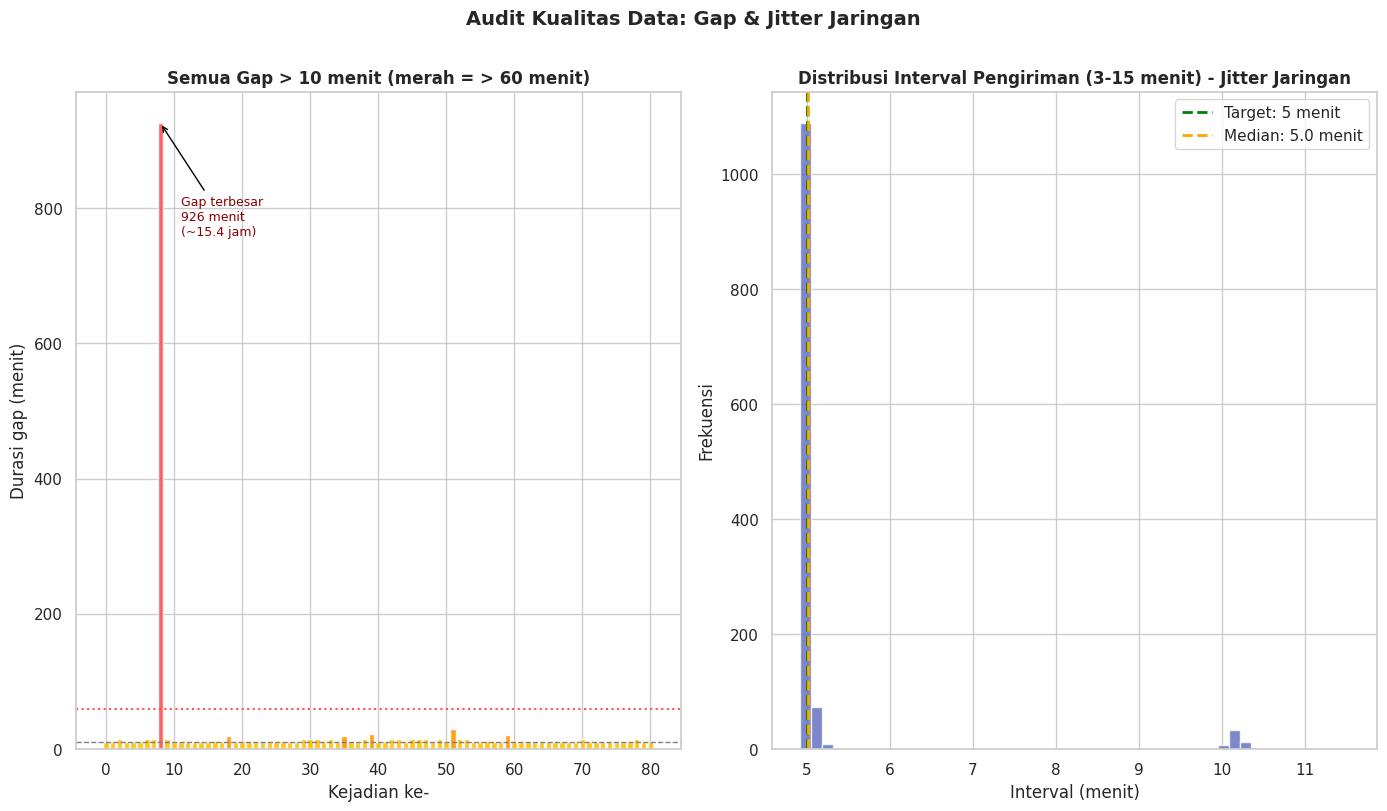


Insight:
  Sebagian besar data dikirim mendekati 5 menit (median: 5.0 min)
  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026
  Sisa 80 gap adalah jitter biasa (<35 menit)


In [9]:
# visualisasi gap (timeline dan distribusi interval)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# plot 1: bar chart gap
ax1 = axes[0]
big_gaps_sorted = big_gaps.sort_values('timestamp')
col_bars = ['#FF5252' if g > 60 else '#FF9800' if g > 20 else '#FFC107'
            for g in big_gaps_sorted['gap_menit']]
ax1.bar(range(len(big_gaps_sorted)), big_gaps_sorted['gap_menit'].values,
        color=col_bars, edgecolor='white', alpha=0.9)
ax1.axhline(y=10, color='gray', linestyle='--', lw=1, label='Threshold 10 menit')
ax1.axhline(y=60, color='#FF5252', linestyle=':', lw=1.5, label='Threshold 1 jam')
ax1.set_xlabel('Kejadian ke-')
ax1.set_ylabel('Durasi gap (menit)')
ax1.set_title('Semua Gap > 10 menit (merah = > 60 menit)', fontweight='bold')

# anotasi gap terbesar
max_idx = big_gaps_sorted['gap_menit'].idxmax()
max_pos = list(big_gaps_sorted.index).index(max_idx)
max_val = big_gaps_sorted.loc[max_idx, 'gap_menit']
ax1.annotate(f"Gap terbesar\n{max_val:.0f} menit\n(~15.4 jam)",
             xy=(max_pos, max_val),
             xytext=(max_pos + 3, max_val * 0.82),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='darkred')

# plot 2: histogram interval
ax2 = axes[1]
interval_trim = q[(q >= 3) & (q <= 15)]
ax2.hist(interval_trim, bins=50, color='#5C6BC0', alpha=0.8, edgecolor='white')
ax2.axvline(x=5, color='green', linestyle='--', lw=2, label='Target: 5 menit')
ax2.axvline(x=q.median(), color='orange', linestyle='--', lw=2, label=f'Median: {q.median():.1f} menit')
ax2.set_xlabel('Interval (menit)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Interval Pengiriman (3-15 menit) - Jitter Jaringan', fontweight='bold')
ax2.legend()

plt.suptitle('Audit Kualitas Data: Gap & Jitter Jaringan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nInsight:')
print(f'  Sebagian besar data dikirim mendekati 5 menit (median: {q.median():.1f} min)')
print('  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026')
print(f'  Sisa {len(big_gaps)-1} gap adalah jitter biasa (<35 menit)')

## 5. Handling Missing Values

### Strategi Imputasi

| Variabel | Metode | Alasan |
|----------|--------|--------|
| Suhu & Kelembapan | **Interpolasi linear** | Perubahan gradual, aman untuk gap pendek–menengah |
| Cahaya | **Forward fill** | Cahaya bisa berubah tiba-tiba, ffill lebih konservatif |
| Kondisi (TERANG/GELAP) | **Forward fill** | Variabel kategorikal |

> **Catatan:** Gap ~15 jam di-*flag* dengan warna berbeda dalam visualisasi agar interpretasi tidak menyesatkan, data di area merah adalah interpolasi jarak jauh, bukan data real.

In [11]:
# reindex ke grid 5 menit penuh
start    = df.index.min().floor('5min')
end      = df.index.max().ceil('5min')
full_idx = pd.date_range(start=start, end=end, freq='5min', tz='Asia/Jakarta')

df_full  = df.reindex(full_idx, method='nearest', tolerance=pd.Timedelta('3min'))
df_full.index_name = 'timestamp'
df_full['is_original'] = ~df_full['suhu'].isna()

n_total   = len(df_full)
n_asli    = df_full['is_original'].sum()
n_missing = (~df_full['is_original']).sum()

print(f'Total timestep 5-menit : {n_total}')
print(f'Data asli              : {n_asli}  ({n_asli/n_total*100:.1f}%)')
print(f'Baris diimputasi       : {n_missing} ({n_missing/n_total*100:.1f}%)')

# catat lokasi gap terbesar untuk visualisasi
df_temp3 = df.reset_index()
df_temp3['gap'] = df_temp3['timestamp'].diff().dt.total_seconds() / 60
big_gap_times = df_temp3[df_temp3['gap'] > 60].copy()
big_gap_times['start'] = df_temp3.loc[big_gap_times.index - 1, 'timestamp'].values
big_gap_times = big_gap_times[['timestamp', 'gap', 'start']].rename(columns={'timestamp': 'end'})

# imputasi
df_full['suhu']       = df_full['suhu'].interpolate(method='linear')
df_full['kelembapan'] = df_full['kelembapan'].interpolate(method='linear')
df_full['cahaya']     = df_full['cahaya'].ffill()
df_full['kondisi']    = df_full['kondisi'].ffill()

print(f'\nImputasi selesai. missing tersisa: {df_full[["suhu", "kelembapan", "cahaya"]].isna().sum().sum()}')

Total timestep 5-menit : 1561
Data asli              : 1279  (81.9%)
Baris diimputasi       : 282 (18.1%)

Imputasi selesai. missing tersisa: 0


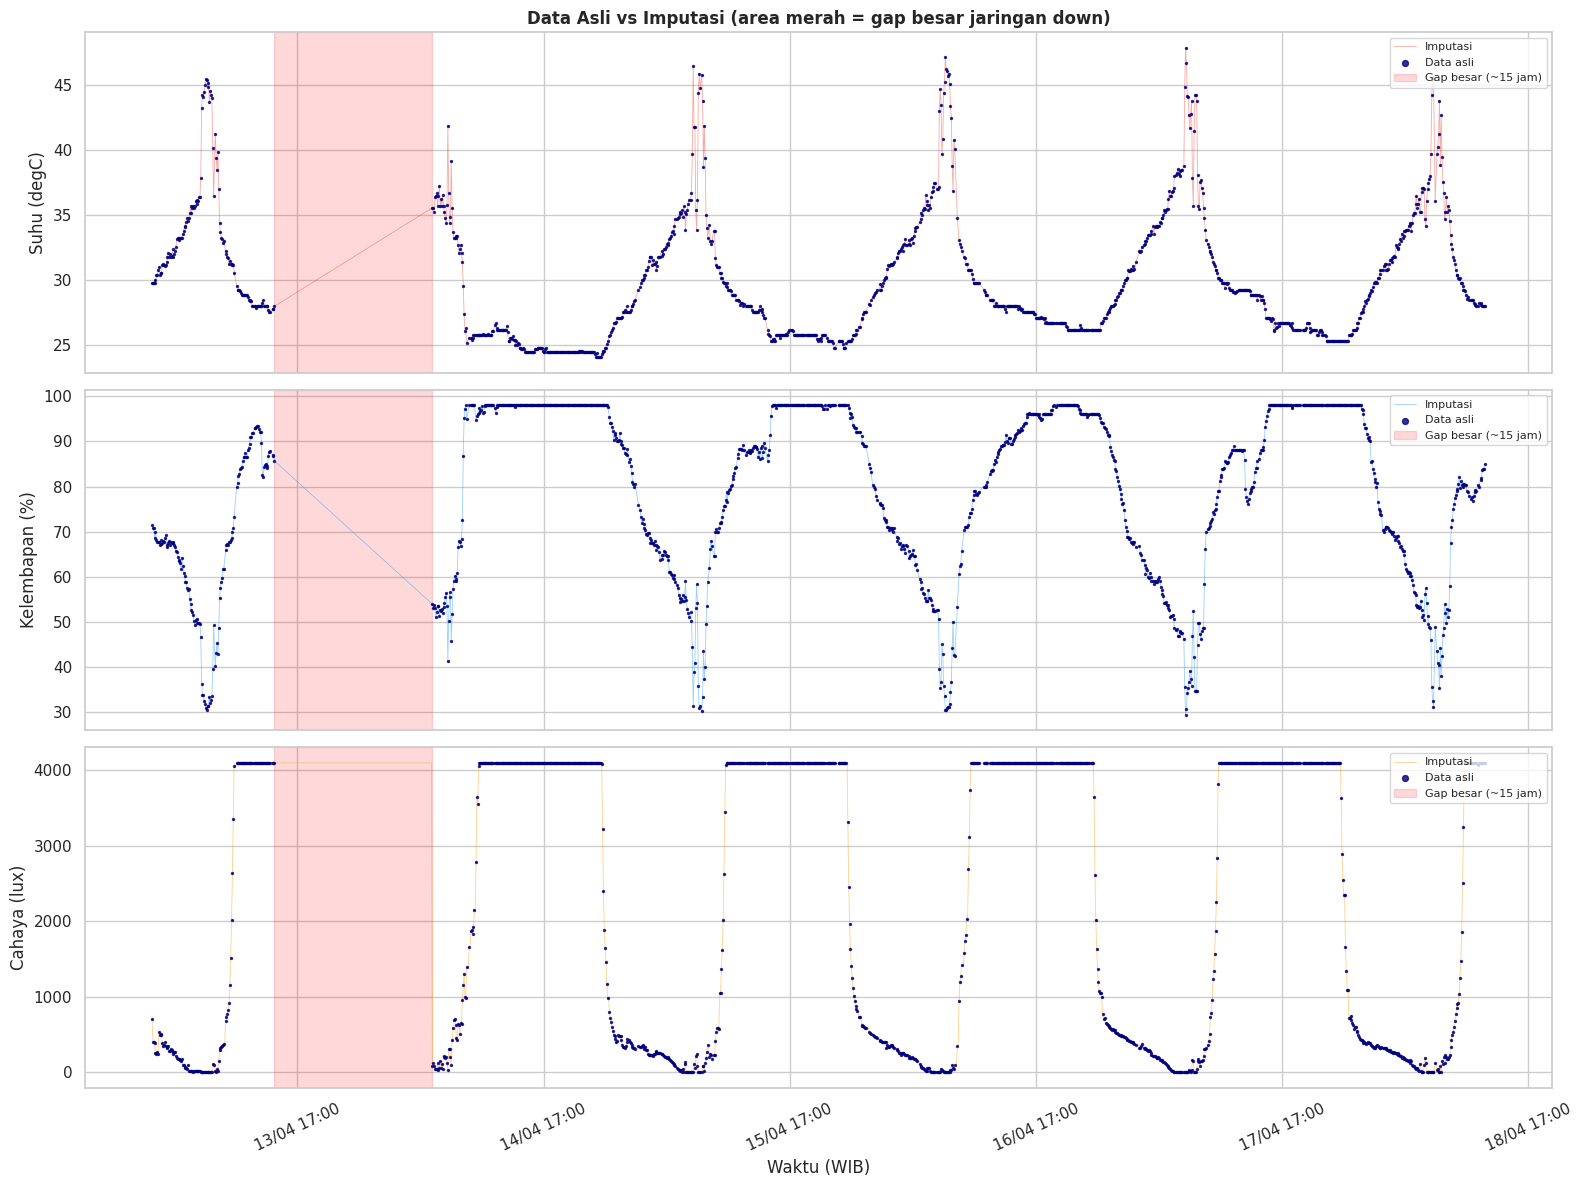

In [14]:
# visualisasi data asli vs imputas
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
cols_viz = [('suhu','#F44336','Suhu (degC)'),
            ('kelembapan','#2196F3','Kelembapan (%)'),
            ('cahaya','#FF9800','Cahaya (lux)')]

df_asli = df_full[df_full['is_original'] == True]

for ax, (col, color, label) in zip(axes, cols_viz):
  ax.plot(df_full.index, df_full[col], color=color, linewidth=0.6, alpha=0.45, label='Imputasi')
  ax.scatter(df_asli.index, df_asli[col], color='navy', s=2, zorder=4, alpha=0.8, label='Data asli')
  for idx2, row in big_gap_times.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.15, color='red',
                   label='Gap besar (~15 jam)' if idx2 == big_gap_times.index[0] else '')
  ax.set_ylabel(label)
  ax.legend(loc='upper right', fontsize=8, markerscale=3)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))

axes[0].set_title("Data Asli vs Imputasi (area merah = gap besar jaringan down)", fontweight='bold')
axes[-1].set_xlabel('Waktu (WIB)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()